In [1]:
import sys
from pathlib import Path

def add_src_to_path():
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        src = p / "src"
        if src.is_dir():
            sys.path.insert(0, str(src))
            print(f"✅ Added to sys.path: {src}")
            return src
    raise FileNotFoundError(
        f"Could not find a 'src' directory by walking up from {here}.\n"
        f"Current working dir is: {here}"
    )

SRC_DIR = add_src_to_path()
print("First sys.path entry:", sys.path[0])


✅ Added to sys.path: /home/user/src
First sys.path entry: /home/user/src


In [2]:
import os
import json
from pathlib import Path
import torch
from torch.utils.data import DataLoader

from models.LIANet import LIANetLight  
from dataset_eval import LIANetFixedGridTimeEvalDataset

ds = LIANetFixedGridTimeEvalDataset(
    topdir_dataset="/home/user/data_shared",
    image_size=128,
    tile_names=["T16TEK", "T16TFK"],
    num_x=24,
    num_y=24,
    num_t=32,
    overlap_mode="both",   # evaluate overlap twice (left+right)
    include_2024=True,
)
run_dir = Path("/home/user/results_shared/fourier_learned_2tile_alltimes_USA_RandomDayTimeSampling/2026-02-10_09-17-01")
data_root = "/home/user/data_shared"
cfg_path = run_dir / "used_parameters.json"
ckpt_dir = run_dir / "model_checkpoints" / "checkpoint_Epoch1000_Iteration2285000.pt"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_grad_enabled(False)

In [ ]:
from collections import OrderedDict

with open(cfg_path, "r") as f:
    cfg = json.load(f)
model_kwargs = cfg.get("model", None)

model = LIANetLight(
    timestamp_dim=cfg["model"]["timestamp_dim"], 
    time_mode="fourier_learned", 
    num_time_frequencies=cfg["model"]["num_time_frequencies"], 
    time_input_dim=cfg["model"]["time_input_dim"], 
    time_mlp_hidden=cfg["model"]["time_mlp_hidden"], 
    levels= cfg["model"]["levels"], 
    n_min=cfg["model"]["n_min"], 
    growth=cfg["model"]["growth"], 
    table_size=cfg["model"]["table_size"],
    feat_dim=cfg["model"]["feat_dim"], 
    complete_tile_size=cfg["model"]["complete_tile_size"], # Sentinel-2 max tile size 
    resunet_backbone_size=cfg["model"]["resunet_backbone_size"], 
    bilinear=cfg["model"]["bilinear"], 
    out_channels=cfg["num_channels"], 
    preproj_channels=cfg["model"]["preproj_channels"], 
    ).to(device)
model.eval()

ckpt = torch.load(str(ckpt_dir), map_location=device)
state = ckpt["model_state_dict"]

if any(k.startswith("module.") for k in state.keys()):
        state = {k.replace("module.", "", 1): v for k, v in state.items()}

missing, unexpected = model.load_state_dict(state, strict=False)
print(f"[ckpt] missing keys: {len(missing)} (showing up to 20): {missing[:20]}")
print(f"[ckpt] unexpected keys: {len(unexpected)} (showing up to 20): {unexpected[:20]}")

[ckpt] missing keys: 0 (showing up to 20): []
[ckpt] unexpected keys: 0 (showing up to 20): []


In [4]:
import numpy as np
def collate_fn(batch):
        # batch is list of dicts
        out = {}
        # stack tensors
        out["delta_days"] = torch.stack([b["delta_days"] for b in batch], dim=0)
        out["doy_sin"] = torch.stack([b["doy_sin"] for b in batch], dim=0)
        out["doy_cos"] = torch.stack([b["doy_cos"] for b in batch], dim=0)
        out["x_s2"] = torch.tensor([b["x_s2"] for b in batch], dtype=torch.float32)
        out["y_s2"] = torch.tensor([b["y_s2"] for b in batch], dtype=torch.float32)
        out["s2data"] = torch.stack(
                [torch.from_numpy(b["s2data"]).float() if isinstance(b["s2data"], np.ndarray) else b["s2data"].float()
                for b in batch],
                dim=0
                )

        # keep strings/ints as lists for logging
        out["tile_name"] = [b["tile_name"] for b in batch]
        out["date_str"] = [b["date_str"] for b in batch]
        out["abs_dt_days"] = torch.stack([b["abs_dt_days"] for b in batch], dim=0)
        out["query_ts"] = torch.stack([b["query_ts"] for b in batch], dim=0)
        out["chosen_ts"] = torch.stack([b["chosen_ts"] for b in batch], dim=0)
        return out

dl = DataLoader(
        ds,
        batch_size=16,
        shuffle=False,   # fixed evaluation
        num_workers=4,
        pin_memory=True,
        collate_fn=collate_fn,
    )

In [5]:
use_amp = True

all_preds = []
all_abs_dt = []

for it, batch in enumerate(dl):
    # print(batch)
    x0 = batch["x_s2"].to(device, non_blocking=True)
    y0 = batch["y_s2"].to(device, non_blocking=True)

    # Choose what you feed as "timestamps" based on time_mode:
    # - fourier_learned/sinusoidal: typically delta_days float [B]
    # - index: time_idx long [B]
    # - mlp: torch.stack([delta_days, doy_sin, doy_cos], dim=1) float [B,3]
    timestamps = batch["delta_days"].to(device, non_blocking=True)

    with torch.no_grad():
        if use_amp and device.type == "cuda":
            with torch.cuda.amp.autocast(True):
                pred = model(
                    timestamps=timestamps,
                    x0=x0,
                    y0=y0,
                    memorized_crop_size=128,
                )
        else:
            pred = model(
                timestamps=timestamps,
                x0=x0,
                y0=y0,
                memorized_crop_size=128,
            )

    # pred: [B, out_channels, H, W]
    all_preds.append(pred.detach().cpu())
    all_abs_dt.append(batch["abs_dt_days"].cpu())
    if it % 50 == 0:
        print(f"[eval] iter={it}/{len(dl)} pred={tuple(pred.shape)}")

preds = torch.cat(all_preds, dim=0)
abs_dt_days = torch.cat(all_abs_dt, dim=0)
print("[done] preds:", preds.shape, "abs_dt_days:", abs_dt_days.shape)


[eval] iter=0/1200 pred=(16, 12, 128, 128)
[eval] iter=50/1200 pred=(16, 12, 128, 128)
[eval] iter=100/1200 pred=(16, 12, 128, 128)
[eval] iter=150/1200 pred=(16, 12, 128, 128)
[eval] iter=200/1200 pred=(16, 12, 128, 128)
[eval] iter=250/1200 pred=(16, 12, 128, 128)
[eval] iter=300/1200 pred=(16, 12, 128, 128)
[eval] iter=350/1200 pred=(16, 12, 128, 128)
[eval] iter=400/1200 pred=(16, 12, 128, 128)
[eval] iter=450/1200 pred=(16, 12, 128, 128)
[eval] iter=500/1200 pred=(16, 12, 128, 128)
[eval] iter=550/1200 pred=(16, 12, 128, 128)
[eval] iter=600/1200 pred=(16, 12, 128, 128)
[eval] iter=650/1200 pred=(16, 12, 128, 128)
[eval] iter=700/1200 pred=(16, 12, 128, 128)
[eval] iter=750/1200 pred=(16, 12, 128, 128)
[eval] iter=800/1200 pred=(16, 12, 128, 128)
[eval] iter=850/1200 pred=(16, 12, 128, 128)
[eval] iter=900/1200 pred=(16, 12, 128, 128)
[eval] iter=950/1200 pred=(16, 12, 128, 128)
[eval] iter=1000/1200 pred=(16, 12, 128, 128)
[eval] iter=1050/1200 pred=(16, 12, 128, 128)
[eval] iter

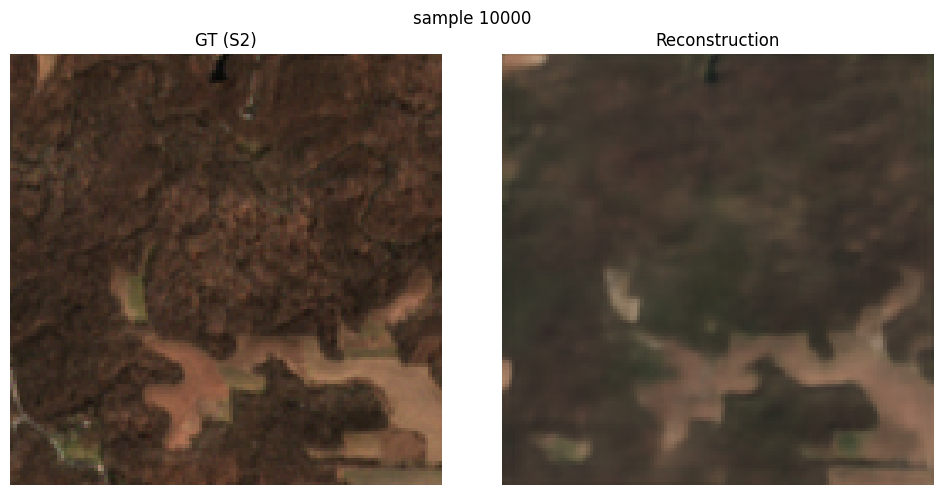

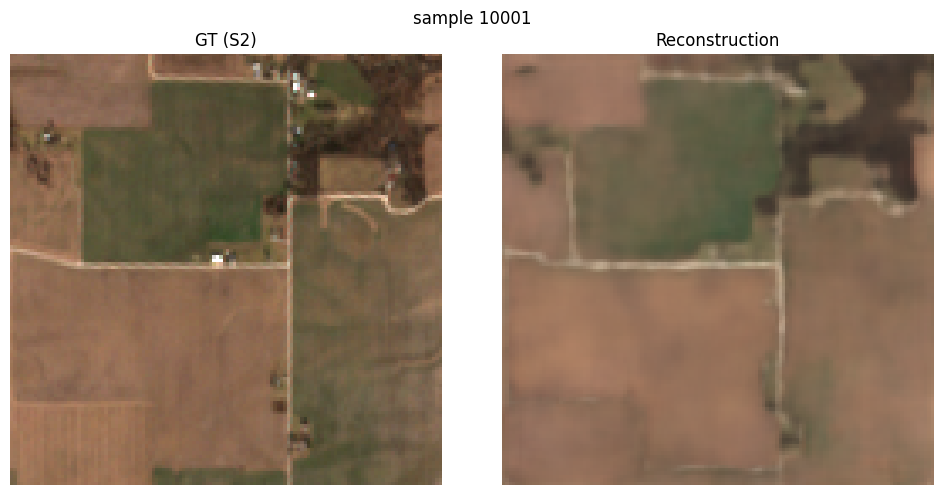

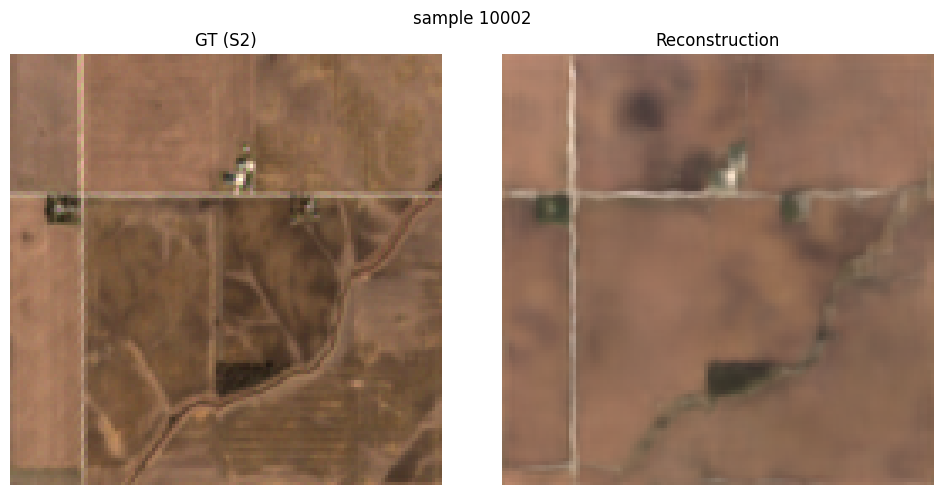

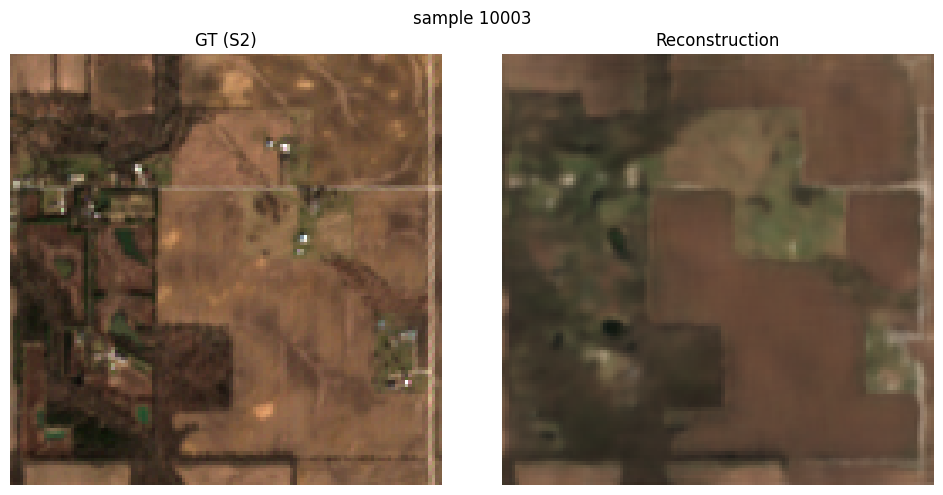

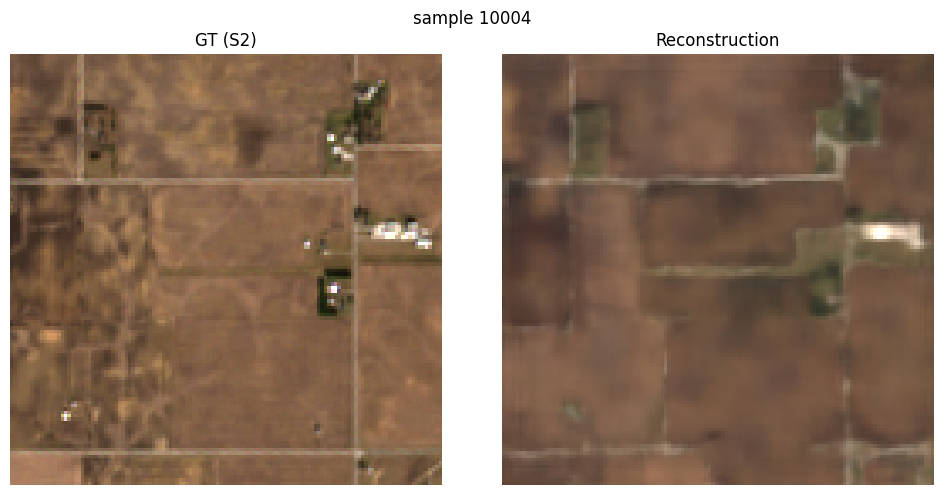

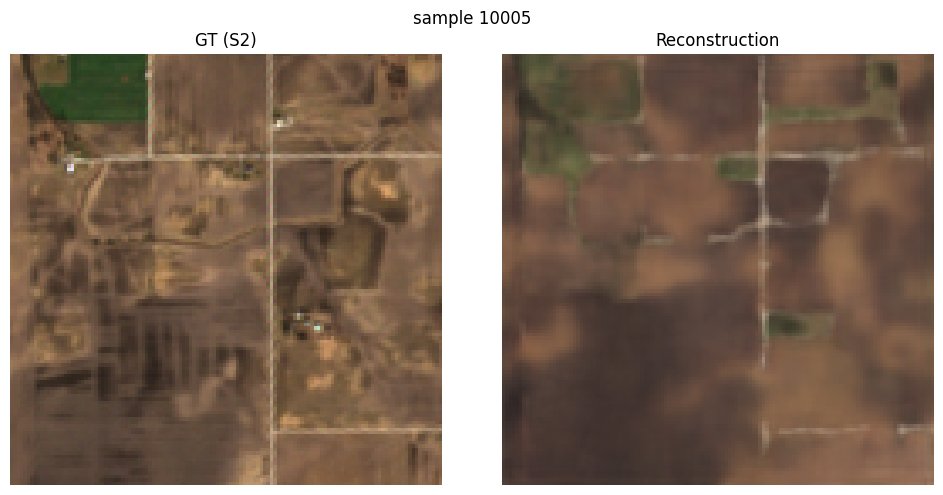

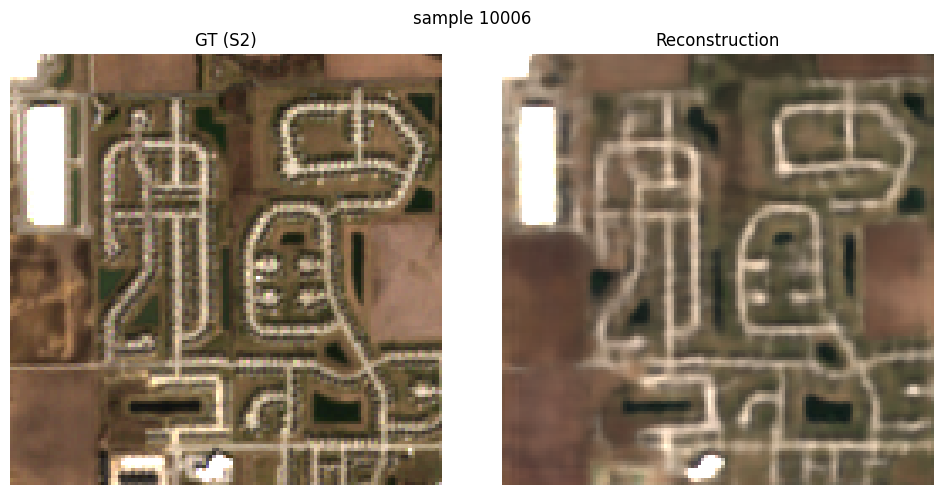

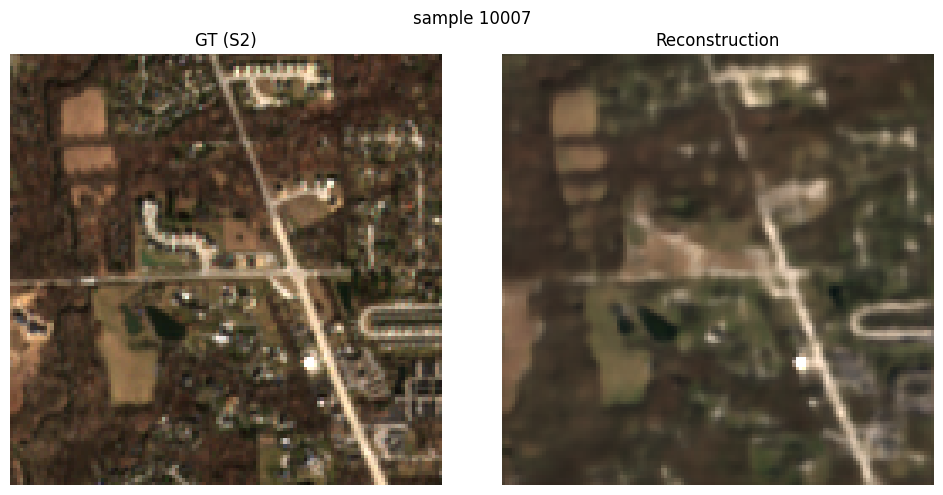

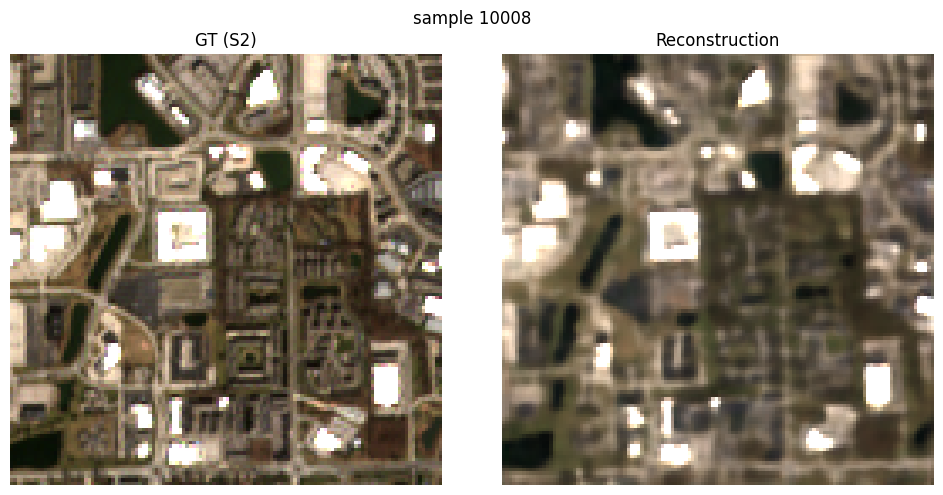

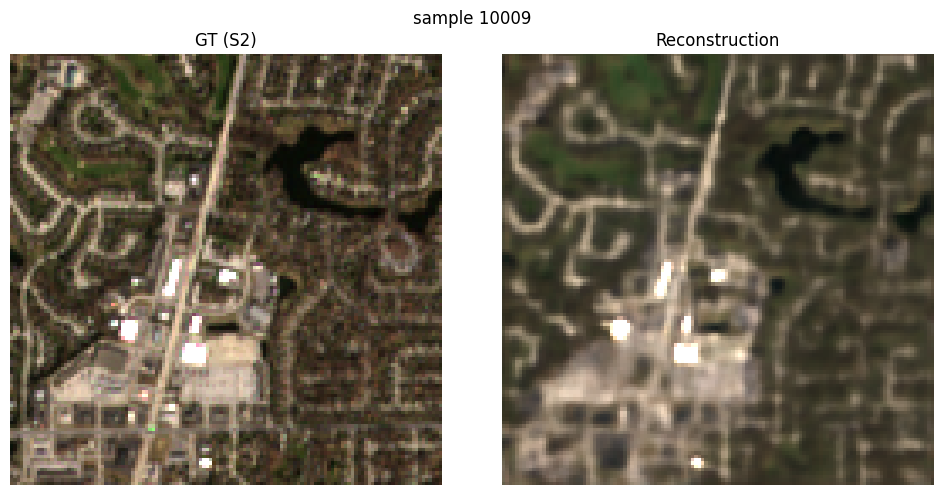

In [6]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from utils import s2_to_rgb

# assuming you already have this somewhere
# from utils import s2_to_rgb

def _to_chw(x):
    """Return numpy float32 [C,H,W] on CPU."""
    if torch.is_tensor(x):
        x = x.detach().float().cpu()
        if x.ndim == 4:
            x = x[0]  # take first in batch
        x = x.numpy()
    else:
        # numpy
        if x.ndim == 4:
            x = x[0]
        x = x.astype(np.float32)
    assert x.ndim == 3, f"Expected [C,H,W], got {x.shape}"
    return x

gts = []
for batch in dl:
    gts.append(batch["s2data"].float().cpu())
gts = torch.cat(gts, dim=0)  # [N,12,H,W]


def show_recon_vs_gt(pred, gt, title_left="GT (S2)", title_right="Reconstruction", suptitle=None):
    """
    pred, gt: torch.Tensor or np.ndarray, either [C,H,W] or [B,C,H,W]
    Uses your s2_to_rgb() to visualize.
    """

    pred_chw = _to_chw(pred)
    gt_chw   = _to_chw(gt)

    # Your function should return an RGB image, typically [H,W,3] in 0..1 or 0..255
    gt_rgb   = s2_to_rgb(gt_chw)      # <- you said we can use this
    pred_rgb = s2_to_rgb(pred_chw)

    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    axs[0].imshow(gt_rgb)
    axs[0].set_title(title_left)
    axs[0].axis("off")

    axs[1].imshow(pred_rgb)
    axs[1].set_title(title_right)
    axs[1].axis("off")

    if suptitle is not None:
        fig.suptitle(suptitle)

    plt.tight_layout()
    plt.show()


# ----------------------------
# Example usage with saved outputs
# ----------------------------
# Suppose:
#   preds: torch.Tensor [N,12,H,W]
#   gts:   torch.Tensor [N,12,H,W]  (or you re-run dl once and store s2data)
# Or if you kept per-sample metadata lists (tile/date/x/y), you can include it in suptitle.

i = 0
for i in range(10000,10010):  # show first 10 samples
    show_recon_vs_gt(
        pred=preds[i],                  # [12,H,W]
        gt=gts[i],                      # [12,H,W]
        suptitle=f"sample {i}"
    )


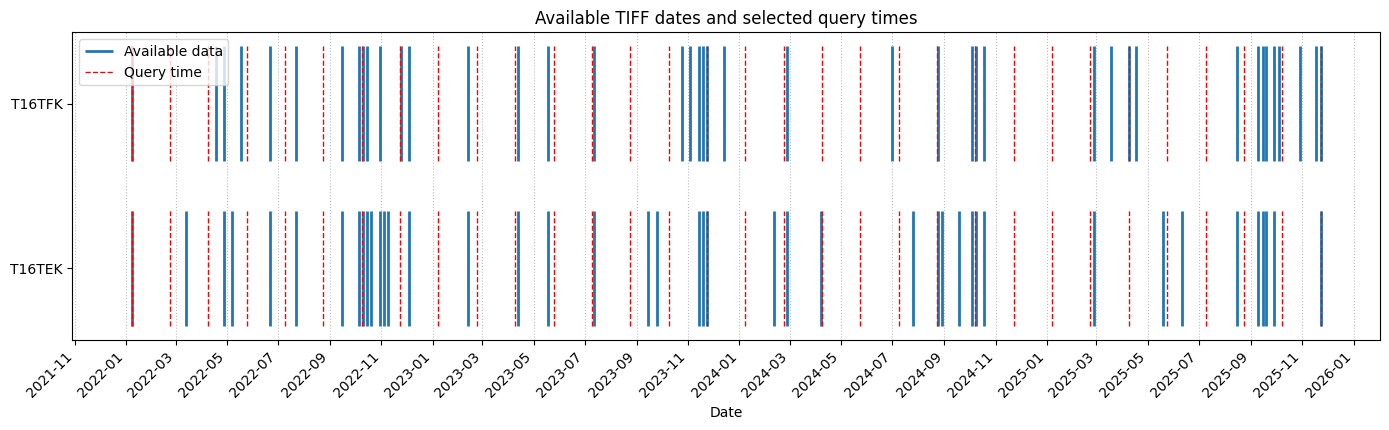

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

def _ts_to_dt64(ts_arr):
    # ts_arr: array of unix seconds (int)
    ts_arr = np.asarray(ts_arr, dtype=np.int64)
    return np.array([datetime.utcfromtimestamp(int(t)) for t in ts_arr], dtype=object)

def plot_available_vs_query_times(ds, show_chosen=False, title="Available TIFF dates and selected query times"):
    """
    ds: your LIANetFixedGridTimeEvalDataset instance.
    show_chosen: if True, also plot chosen_ts (nearest acquisition used) as separate ticks.
    """

    tiles = ds.tile_names_list
    n = len(tiles)

    # Collect unique query times per tile from ds.samples
    query_by_tile = {t: [] for t in tiles}
    chosen_by_tile = {t: [] for t in tiles}

    for s in ds.samples:
        query_by_tile[s["tile_name"]].append(int(s["query_ts"]))

    # Unique + sorted
    for t in tiles:
        query_by_tile[t] = np.unique(np.asarray(query_by_tile[t], dtype=np.int64))

    # If requested, compute chosen_ts per query per tile (exactly like __getitem__)
    if show_chosen:
        for t in tiles:
            times = ds.tile_times[t]
            qts = query_by_tile[t]
            # nearest per query
            idx = np.argmin(np.abs(times[None, :] - qts[:, None]), axis=1)
            chosen_by_tile[t] = times[idx]

    # ---- Plot ----
    fig, ax = plt.subplots(figsize=(14, 3 + 0.7 * n))

    y_positions = np.arange(n)  # 0..n-1
    ax.set_yticks(y_positions)
    ax.set_yticklabels(tiles)

    # We’ll use vlines so we don’t have to set explicit colors.
    # Matplotlib default cycle will distinguish them by style/legend.
    for yi, tile in enumerate(tiles):
        avail_dt = _ts_to_dt64(ds.tile_times[tile])
        query_dt = _ts_to_dt64(query_by_tile[tile])

        # available observations
        ax.vlines(avail_dt, yi - 0.35, yi + 0.35, linewidth=2, label="Available data" if yi == 0 else None)

        # query times (dashed)
        ax.vlines(query_dt, yi - 0.35, yi + 0.35, linewidth=1, colors="red", linestyles="dashed",
                  label="Query time" if yi == 0 else None)

        if show_chosen:
            chosen_dt = _ts_to_dt64(chosen_by_tile[tile])
            ax.vlines(chosen_dt, yi - 0.20, yi + 0.20, linewidth=1, colors="black", linestyles="dotted",
                      label="Chosen (nearest)" if yi == 0 else None)

    ax.set_title(title)
    ax.set_xlabel("Date")

    # date formatting
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

    ax.grid(True, axis="x", linestyle=":", color="gray", alpha=0.5)
    ax.legend(loc="upper left")
    plt.tight_layout()
    plt.show()


# Example:
plot_available_vs_query_times(ds, show_chosen=False)
# plot_available_vs_query_times(ds, show_chosen=True)


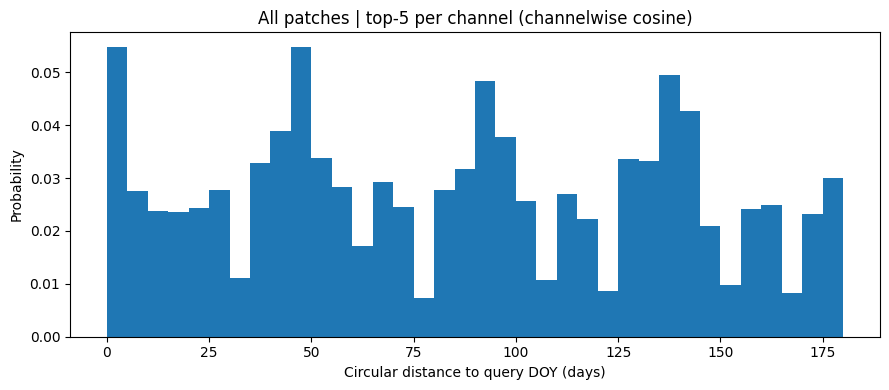

In [11]:
# preds: [N,12,128,128] aligned with ds (shuffle=False)
from utils import _preprocess_S2
hist_all, hist_region, bin_edges = cumulative_topk_circ_hist_fast(
    ds=ds,
    preds=preds,
    data_root="/home/user/data_shared",
    preprocess_fn=_preprocess_S2,
    top_k=10,
    channels=list(range(12)),              # all channels, channelwise
    bin_edges=np.arange(0, 181, 5),
    normalize=True,
    split_by_region=True,
    use_float16_obs=True,
)

plot_hist(hist_all, bin_edges, title="All patches | top-5 per channel (channelwise cosine)")

# Optional: region breakdown (useful to show overlap has different candidate set)
# if hist_region is not None:
#     for r, h in hist_region.items():
#         if np.sum(h) > 0:
#             plot_hist(h, bin_edges, title=f"{r} | top-5 per channel")


In [9]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from datetime import datetime
from collections import defaultdict
import rasterio as rio

# ----------------------------
# time helpers
# ----------------------------
def doy_from_ts(ts: int) -> int:
    return datetime.utcfromtimestamp(int(ts)).timetuple().tm_yday  # 1..365/366

def circ_doy_dist(d1: int, d2: int, period: int = 365) -> int:
    d = abs(int(d1) - int(d2))
    return min(d, period - d)

def which_region(ds, x_s2_latent: int) -> str:
    if len(ds.tile_names_list) < 2:
        return "single"
    shift = ds.single_tile_width - ds.overlap_x
    overlap_left = shift
    overlap_right = ds.single_tile_width
    if overlap_left <= x_s2_latent < overlap_right:
        return "overlap"
    elif x_s2_latent < overlap_left:
        return "left_only"
    else:
        return "right_only"

# ----------------------------
# build observation indices
# ----------------------------
def build_union_observation_index(ds):
    tiles = ds.tile_names_list
    tile_obs = {}
    for t in tiles:
        tile_obs[t] = {
            "times": np.asarray(ds.tile_times[t], dtype=np.int64),
            "files": list(ds.tile_files[t]),
        }

    union_obs = None
    if len(tiles) == 2:
        union = []
        for t in tiles:
            for ts, fn in zip(tile_obs[t]["times"], tile_obs[t]["files"]):
                union.append((int(ts), t, fn))
        union.sort(key=lambda x: x[0])
        union_obs = {
            "times": np.asarray([u[0] for u in union], dtype=np.int64),
            "tiles": [u[1] for u in union],
            "files": [u[2] for u in union],
        }
    return tile_obs, union_obs

# ----------------------------
# channelwise cosine core
# ----------------------------
@torch.no_grad()
def normalize_chw_per_channel(x_chw: torch.Tensor, eps=1e-8) -> torch.Tensor:
    """
    x_chw: [C,H,W] -> [C,N] normalized per channel over N=H*W
    """
    x = x_chw.float()
    C, H, W = x.shape
    x = x.view(C, H * W)  # [C,N]
    n = x.norm(dim=1, keepdim=True) + eps
    return x / n

@torch.no_grad()
def sims_tc_from_pred_and_obs_normed(pred_norm_cn: torch.Tensor, obs_norm_tcn: torch.Tensor) -> torch.Tensor:
    """
    pred_norm_cn: [C,N]
    obs_norm_tcn: [T,C,N]
    returns sims_tc: [T,C]
    """
    return (obs_norm_tcn * pred_norm_cn.unsqueeze(0)).sum(dim=2)

# ----------------------------
# IO cache for open datasets (big speedup)
# ----------------------------
class RasterOpenCache:
    def __init__(self, max_open=32):
        self.max_open = max_open
        self._cache = {}      # path -> dataset
        self._order = []      # LRU order

    def get(self, path: str):
        if path in self._cache:
            # refresh LRU
            self._order.remove(path)
            self._order.append(path)
            return self._cache[path]
        # open new
        ds = rio.open(path)
        self._cache[path] = ds
        self._order.append(path)
        # evict
        while len(self._order) > self.max_open:
            old = self._order.pop(0)
            try:
                self._cache[old].close()
            except Exception:
                pass
            del self._cache[old]
        return ds

    def close(self):
        for p, ds in self._cache.items():
            try:
                ds.close()
            except Exception:
                pass
        self._cache.clear()
        self._order.clear()

# ----------------------------
# main: cumulative histogram (fast)
# ----------------------------
def cumulative_topk_circ_hist_fast(
    ds,
    preds,                      # [N,C,H,W]
    data_root: str,
    preprocess_fn,              # _preprocess_S2
    top_k: int = 5,
    channels=None,              # None -> all
    bin_edges=None,             # default 0..180 by 15
    normalize=True,
    split_by_region=True,
    max_groups=None,            # debug/limit
    max_open_rasters=32,
    use_float16_obs=True,       # save memory & speed
):
    preds = preds.detach().cpu()
    N, C, H, W = preds.shape

    if channels is None:
        channels = list(range(C))
    channels = list(channels)

    if bin_edges is None:
        bin_edges = np.arange(0, 181, 15, dtype=np.int32)
    bin_edges = np.asarray(bin_edges, dtype=np.int32)
    nb = len(bin_edges) - 1

    tile_obs, union_obs = build_union_observation_index(ds)

    # 1) group sample indices by spatial location in latent space (x_s2, y_s2)
    groups = defaultdict(list)
    # store minimal per-sample meta to avoid calling ds[i] repeatedly (would read rasters)
    metas = []
    for i in range(len(ds)):
        s = ds.samples[i]  # safe: doesn't read anything
        groups[(int(s["x_s2"]), int(s["y_s2"]))].append(i)
        metas.append(s)

    hist_all = np.zeros(nb, dtype=np.int64)
    hist_region = {r: np.zeros(nb, dtype=np.int64) for r in ["left_only", "right_only", "overlap", "single"]}

    shift = ds.single_tile_width - ds.overlap_x if len(ds.tile_names_list) >= 2 else ds.single_tile_width
    opener = RasterOpenCache(max_open=max_open_rasters)

    try:
        for gi, ((x_lat, y_lat), idxs) in enumerate(groups.items()):
            if max_groups is not None and gi >= max_groups:
                break

            # region determines which observation set to compare against (tile-only vs union)
            region = which_region(ds, x_lat)

            # pick a representative sample to know which tile this group belongs to (only needed for non-overlap)
            rep = metas[idxs[0]]
            rep_tile = rep["tile_name"]

            # build observation list for this spatial location
            if region == "overlap" and union_obs is not None and len(ds.tile_names_list) == 2:
                obs_times = union_obs["times"]
                obs_sources = list(zip(union_obs["tiles"], union_obs["files"]))  # (tile, file)
            else:
                obs_times = tile_obs[rep_tile]["times"]
                obs_sources = [(rep_tile, fn) for fn in tile_obs[rep_tile]["files"]]

            # 2) Read & preprocess all observations ONCE for this (x,y), and store normalized [T,C,N]
            T = len(obs_times)
            obs_norm = []

            for (obs_tile, obs_file) in obs_sources:
                obs_tile_idx = ds.tile_names_list.index(obs_tile)
                x_offset = obs_tile_idx * shift
                x_img = int(x_lat - x_offset)
                y_img = int(y_lat)

                x_img = max(0, min(x_img, ds.single_tile_width - ds.image_size))
                y_img = max(0, min(y_img, ds.single_tile_width - ds.image_size))

                path = f"{data_root}/{obs_tile}/{obs_file}"
                src = opener.get(path)
                window = rio.windows.Window(col_off=x_img, row_off=y_img, width=ds.image_size, height=ds.image_size)
                arr = src.read(window=window)  # [C,H,W] numpy
                arr = preprocess_fn(arr)       # numpy [C,H,W]
                obs_chw = torch.from_numpy(arr)

                obs_cn = normalize_chw_per_channel(obs_chw)  # [C,N]
                if use_float16_obs:
                    obs_cn = obs_cn.to(torch.float16)
                else:
                    obs_cn = obs_cn.to(torch.float32)
                obs_norm.append(obs_cn)

            obs_norm_tcn = torch.stack(obs_norm, dim=0)  # [T,C,N], float16/32

            # Precompute obs DOYs once
            obs_doys = np.array([doy_from_ts(int(ts)) for ts in obs_times], dtype=np.int32)

            # 3) For each sample at this (x,y), compute sims fast and accumulate top-K distances
            for i in idxs:
                # query time from ds.samples (no IO)
                q_ts = int(metas[i]["query_ts"])
                doy_q = doy_from_ts(q_ts)

                pred_chw = preds[i]                       # [C,H,W]
                pred_cn = normalize_chw_per_channel(pred_chw)  # [C,N] float32

                # match dtype for multiply
                if obs_norm_tcn.dtype == torch.float16:
                    pred_cn = pred_cn.to(torch.float16)

                sims_tc = sims_tc_from_pred_and_obs_normed(pred_cn, obs_norm_tcn)  # [T,C]
                sims_tc = sims_tc[:, channels]  # [T, Csel]

                # top-k indices per channel (no cross-channel pooling)
                # sims_tc: [T,Csel] -> topk over T for each channel
                top_vals, top_idx = torch.topk(sims_tc, k=top_k, dim=0, largest=True, sorted=False)
                top_idx = top_idx.cpu().numpy()  # [top_k, Csel]

                # convert those top indices to circular DOY distances and bin them
                for cc in range(top_idx.shape[1]):
                    for kk in range(top_k):
                        j = int(top_idx[kk, cc])
                        d = circ_doy_dist(int(obs_doys[j]), int(doy_q), period=365)

                        b = int(np.searchsorted(bin_edges, d, side="right") - 1)
                        if 0 <= b < nb:
                            hist_all[b] += 1
                            if split_by_region:
                                hist_region[region][b] += 1

        # normalize
        if normalize:
            denom = hist_all.sum() if hist_all.sum() > 0 else 1
            hist_all = hist_all.astype(np.float64) / denom
            if split_by_region:
                for r in hist_region:
                    d = hist_region[r].sum()
                    if d > 0:
                        hist_region[r] = hist_region[r].astype(np.float64) / d

        return hist_all, (hist_region if split_by_region else None), bin_edges

    finally:
        opener.close()

def plot_hist(hist, bin_edges, title, ylabel=None):
    centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    widths = (bin_edges[1:] - bin_edges[:-1])
    plt.figure(figsize=(9,4))
    plt.bar(centers, hist, width=widths, align="center")
    plt.xlabel("Circular distance to query DOY (days)")
    plt.ylabel(ylabel if ylabel else ("Probability" if hist.dtype == np.float64 else "Count"))
    plt.title(title)
    plt.tight_layout()
    plt.show()


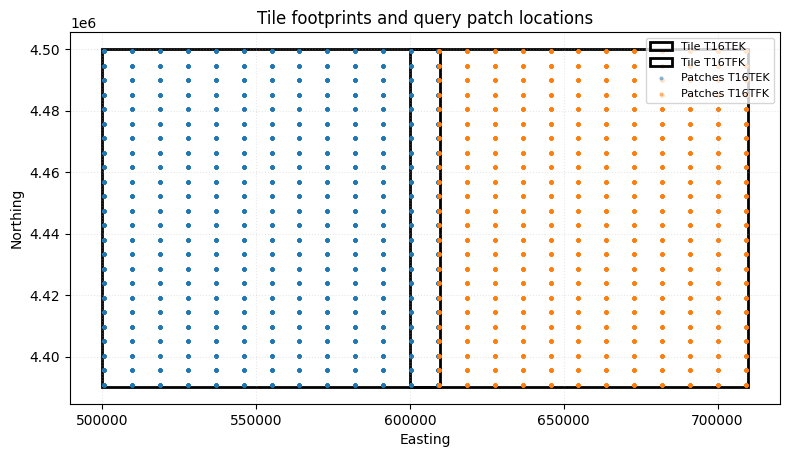

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import rasterio as rio
from rasterio.windows import Window

def _open_tile_sources(ds, data_root):
    srcs = {}
    for tile in ds.tile_names_list:
        tif_name = ds.tile_files[tile][0]
        tif_path = f"{data_root}/{tile}/{tif_name}"
        srcs[tile] = rio.open(tif_path)
    return srcs

def _close_tile_sources(srcs):
    for src in srcs.values():
        try:
            src.close()
        except Exception:
            pass

# Plot tile footprints + patch centers from ds.samples
srcs = _open_tile_sources(ds, data_root)
try:
    fig, ax = plt.subplots(figsize=(8, 6))

    # Tile footprints
    for tile, src in srcs.items():
        b = src.bounds
        rect = plt.Rectangle(
            (b.left, b.bottom),
            b.right - b.left,
            b.top - b.bottom,
            fill=False,
            linewidth=2,
            label=f"Tile {tile}",
        )
        ax.add_patch(rect)

    # Patch centers (optionally downsample for clarity)
    max_points = 10000
    idxs = np.arange(len(ds.samples))
    if len(idxs) > max_points:
        idxs = np.linspace(0, len(ds.samples) - 1, num=max_points, dtype=int)

    centers_x = []
    centers_y = []
    centers_tile = []
    for i in idxs:
        s = ds.samples[i]
        tile = s["tile_name"]
        src = srcs[tile]
        window = Window(
            col_off=int(s["x_s2_img"]),
            row_off=int(s["y_s2_img"]),
            width=ds.image_size,
            height=ds.image_size,
        )
        left, bottom, right, top = rio.windows.bounds(window, src.transform)
        centers_x.append((left + right) * 0.5)
        centers_y.append((bottom + top) * 0.5)
        centers_tile.append(tile)

    centers_x = np.asarray(centers_x)
    centers_y = np.asarray(centers_y)
    centers_tile = np.asarray(centers_tile)

    for tile in ds.tile_names_list:
        mask = centers_tile == tile
        ax.scatter(
            centers_x[mask],
            centers_y[mask],
            s=4,
            alpha=0.4,
            label=f"Patches {tile}",
        )

    ax.set_title("Tile footprints and query patch locations")
    ax.set_xlabel("Easting")
    ax.set_ylabel("Northing")
    ax.set_aspect("equal", adjustable="box")
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, linestyle=":", alpha=0.3)
    plt.tight_layout()
    plt.show()
finally:
    _close_tile_sources(srcs)